# Sleep Disorder Risk Predictor

**Goal:** Build a small machine learning classifier that predicts a person's sleep disorder risk category from lifestyle, health, and sleep-related features.

This notebook includes:

1. Data loading and basic inspection  
2. Exploratory data analysis  
3. Data preprocessing  
4. Model training and comparison  
5. Final model evaluation  
6. Feature importance  
7. Example prediction for a new person

**Target variable:** `sleep_disorder_risk`

In [9]:
import sys
!{sys.executable} -m pip install numpy pandas scikit-learn matplotlib seaborn

  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---------------------------------------- 0/2 [matplotlib]
   ---


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Usi


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
print(np.__version__)

2.4.4


## 1. Import Libraries

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)

## 2. Load the Dataset

The CSV file should be in the same folder as this notebook. If needed, change the file path below.

In [4]:
DATA_PATH = "sleep_health_dataset.csv"

try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    # This fallback path works when running inside the original ChatGPT workspace.
    df = pd.read_csv("/mnt/data/sleep_health_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100000, 32)


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## 3. Basic Data Inspection

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  alcohol_uni

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_id,100000.0,NaN,NaN,NaN,50000.5,28867.657797,1.0,25000.75,50000.5,75000.25,100000.0
age,100000.0,NaN,NaN,NaN,34.70687,11.036373,18.0,26.0,33.0,42.0,69.0
gender,100000,3,Female,50203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,100000,12,Student,14851,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,26.289673,4.479578,16.0,23.2,26.3,29.3,45.0
country,100000,15,USA,20050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_duration_hrs,100000.0,NaN,NaN,NaN,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,NaN,NaN,NaN,4.871144,1.506517,1.0,3.8,4.9,6.0,10.0
rem_percentage,100000.0,NaN,NaN,NaN,20.243968,3.411354,10.0,18.0,20.3,22.6,30.0
deep_sleep_percentage,100000.0,NaN,NaN,NaN,20.253375,4.251096,5.0,17.4,20.3,23.2,30.0


In [7]:
# Check missing values
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

## 4. Target Variable Distribution

This shows whether the classes are balanced or imbalanced.

In [8]:
target_col = "sleep_disorder_risk"

class_counts = df[target_col].value_counts()
class_percentages = df[target_col].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages
})

target_summary

,count,percentage
sleep_disorder_risk,,
Healthy,54156,54.16
Mild,33479,33.48
Moderate,8299,8.30
Severe,4066,4.07


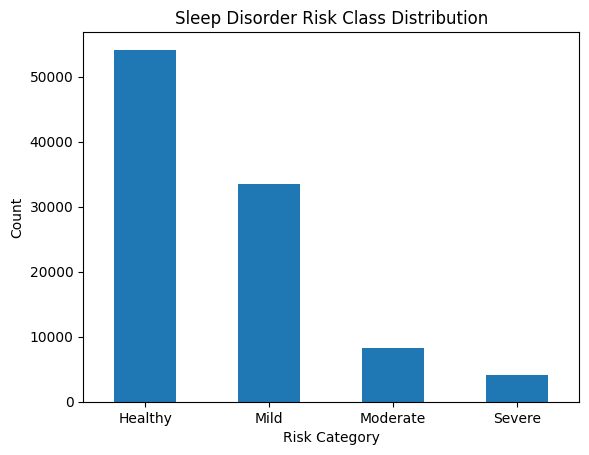

In [9]:
class_counts.plot(kind="bar")
plt.title("Sleep Disorder Risk Class Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 5. Exploratory Data Analysis

These quick charts help show how key features relate to sleep disorder risk.

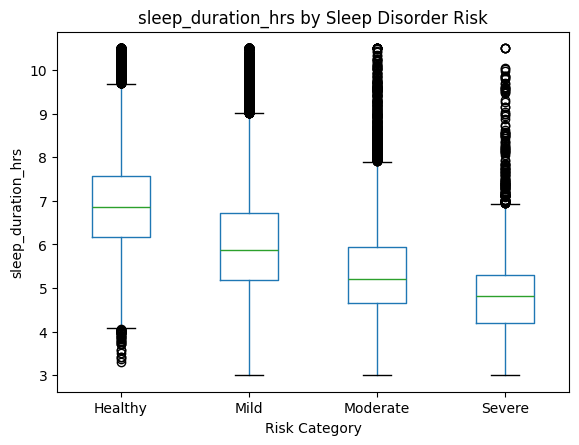

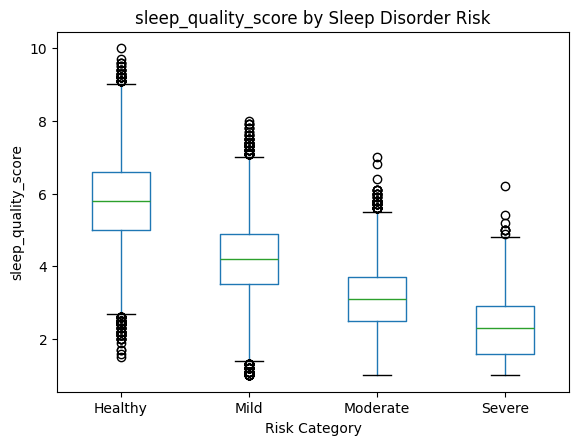

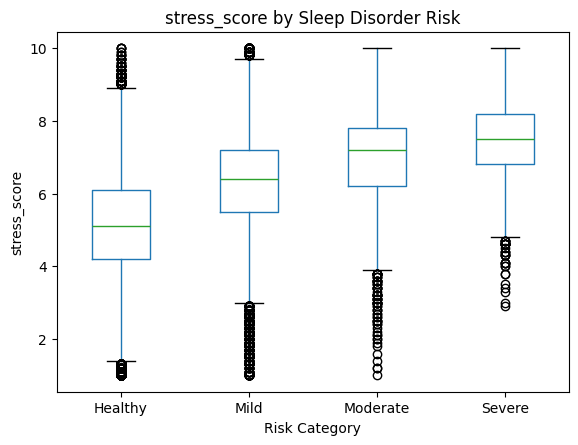

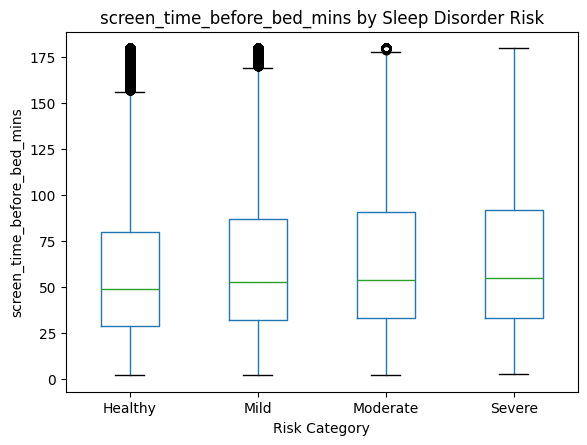

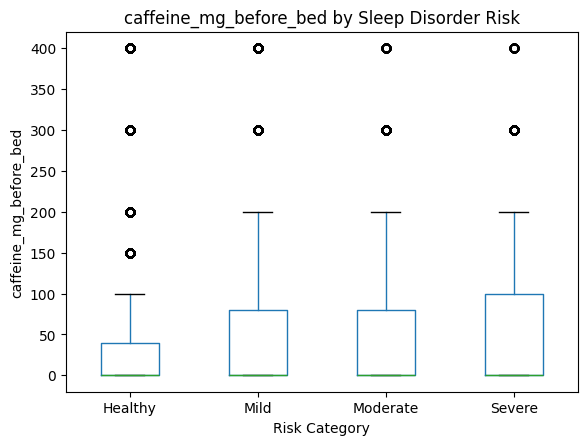

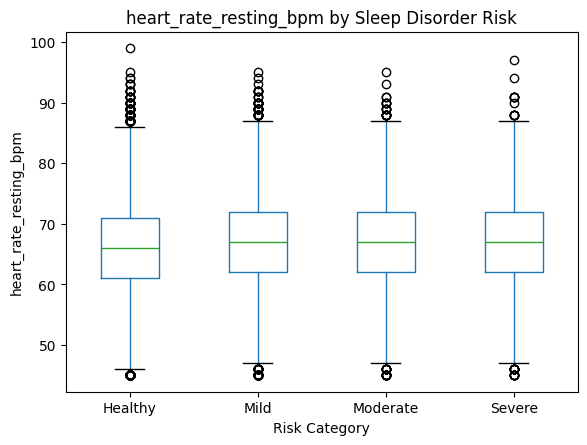

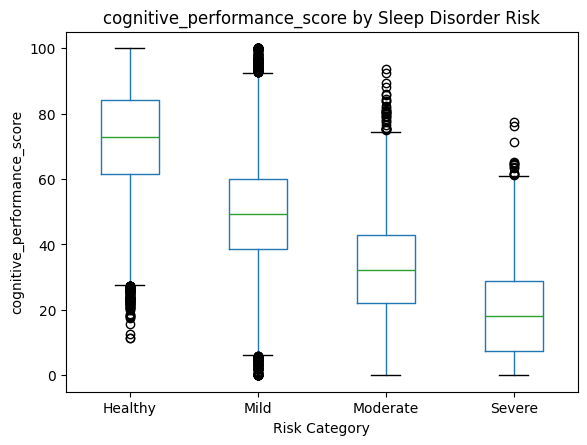

In [10]:
# Numeric feature distributions by target category
important_numeric_features = [
    "sleep_duration_hrs",
    "sleep_quality_score",
    "stress_score",
    "screen_time_before_bed_mins",
    "caffeine_mg_before_bed",
    "heart_rate_resting_bpm",
    "cognitive_performance_score"
]

for col in important_numeric_features:
    if col in df.columns:
        df.boxplot(column=col, by=target_col, grid=False)
        plt.title(f"{col} by Sleep Disorder Risk")
        plt.suptitle("")
        plt.xlabel("Risk Category")
        plt.ylabel(col)
        plt.show()

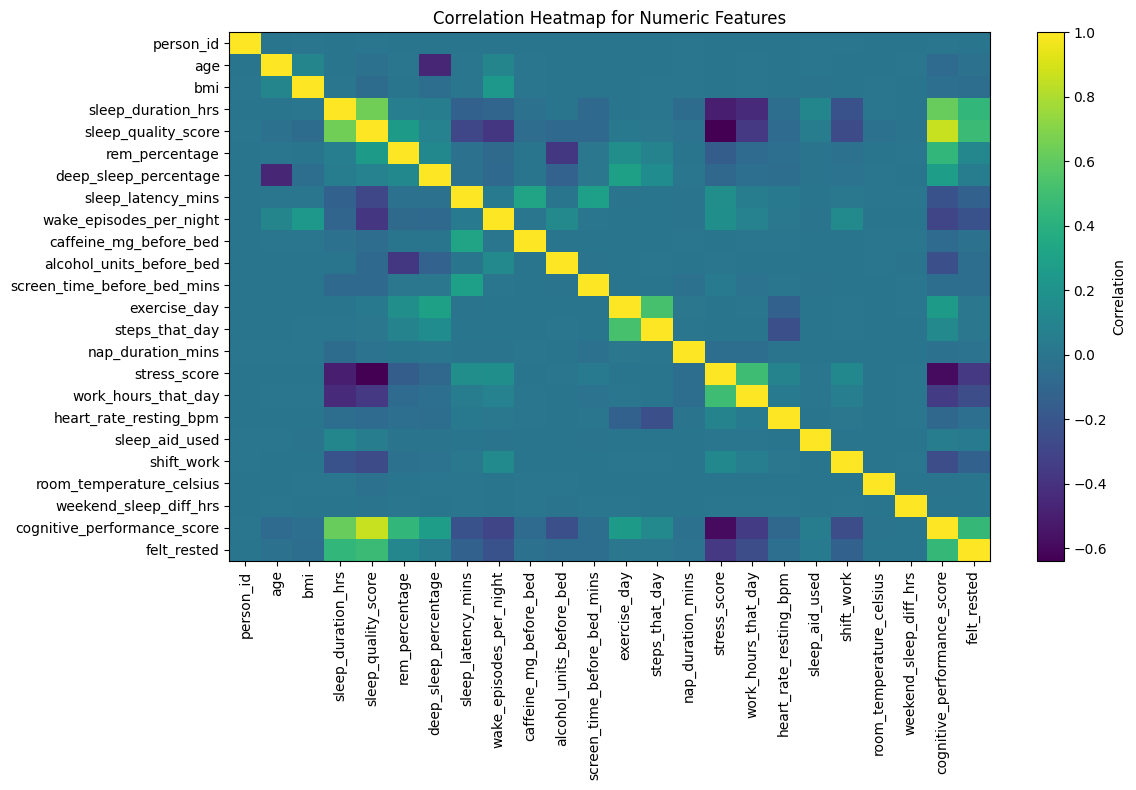

In [11]:
# Correlation heatmap for numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 8))
plt.imshow(numeric_df.corr(), aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(numeric_df.columns)), numeric_df.columns, rotation=90)
plt.yticks(range(len(numeric_df.columns)), numeric_df.columns)
plt.title("Correlation Heatmap for Numeric Features")
plt.tight_layout()
plt.show()

## 6. Choose Features and Target

`person_id` is removed because it is just an identifier.

There are two possible project versions:

- **Full-feature version:** uses all non-ID features. This may produce high accuracy because some columns, such as `sleep_quality_score`, `cognitive_performance_score`, and `felt_rested`, may be closely related to the target.
- **No-leakage version:** removes features that may be too directly connected to the target. This is often better for a realistic prediction project.

This notebook uses the **no-leakage version** by default.

In [12]:
# Columns that should not be model inputs
id_columns = ["person_id"]

# These are potentially too directly related to sleep disorder risk.
# Keeping them may make the model look better than it really is.
potential_leakage_columns = [
    "sleep_quality_score",
    "cognitive_performance_score",
    "felt_rested"
]

# Use no-leakage features by default
columns_to_drop = id_columns + potential_leakage_columns + [target_col]
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

X = df.drop(columns=columns_to_drop)
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Features used:")
print(list(X.columns))

Feature matrix shape: (100000, 27)
Target shape: (100000,)
Features used:
['age', 'gender', 'occupation', 'bmi', 'country', 'sleep_duration_hrs', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type']


## 7. Train/Test Split

`stratify=y` keeps the class proportions similar in the training and test sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (80000, 27)
Test set: (20000, 27)


## 8. Preprocessing Pipeline

The pipeline:

- Fills missing numeric values with the median
- Scales numeric features
- Fills missing categorical values with the most common value
- One-hot encodes categorical features

In [14]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'bmi', 'sleep_duration_hrs', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs']
Categorical features: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']


## 9. Train Baseline Models

We compare two models:

1. **Logistic Regression:** simple and explainable baseline  
2. **Random Forest:** stronger nonlinear model

In [15]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results.append({"model": name, "accuracy": acc})
    fitted_pipelines[name] = pipeline

results_df = pd.DataFrame(results).sort_values("accuracy", ascending=False)
results_df

,model,accuracy
1,Random Forest,0.90565
0,Logistic Regression,0.80290


## 10. Evaluate the Best Model

In [17]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = fitted_pipelines[best_model_name]

print("Best model:", best_model_name)

y_pred = best_pipeline.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Classification Report:")
print(classification_report(y_test, y_pred))

Best model: Random Forest
Accuracy: 0.9056
Classification Report:
              precision    recall  f1-score   support

     Healthy       0.97      0.98      0.97     10831
        Mild       0.85      0.93      0.89      6696
    Moderate       0.71      0.42      0.52      1660
      Severe       0.86      0.69      0.76       813

    accuracy                           0.91     20000
   macro avg       0.84      0.75      0.79     20000
weighted avg       0.90      0.91      0.90     20000



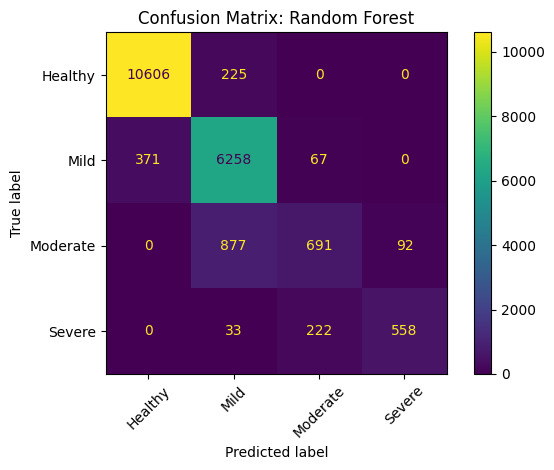

In [18]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=45)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

## 11. Feature Importance

Permutation importance estimates how much model performance drops when each feature is randomly shuffled.

To keep the notebook fast, this section uses a sample of the test set.

In [19]:
# Use a smaller sample for speed
sample_size = min(5000, len(X_test))
X_test_sample = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_test_sample = y_test.loc[X_test_sample.index]

perm = permutation_importance(
    best_pipeline,
    X_test_sample,
    y_test_sample,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
19,mental_health_condition,0.23248,0.003804
5,sleep_duration_hrs,0.21316,0.004688
3,bmi,0.10532,0.004242
9,wake_episodes_per_night,0.09656,0.002905
16,stress_score,0.08988,0.003300
8,sleep_latency_mins,0.07048,0.002402
22,shift_work,0.01756,0.000852
6,rem_percentage,0.00880,0.001575
11,alcohol_units_before_bed,0.00784,0.000637
26,day_type,0.00376,0.001323


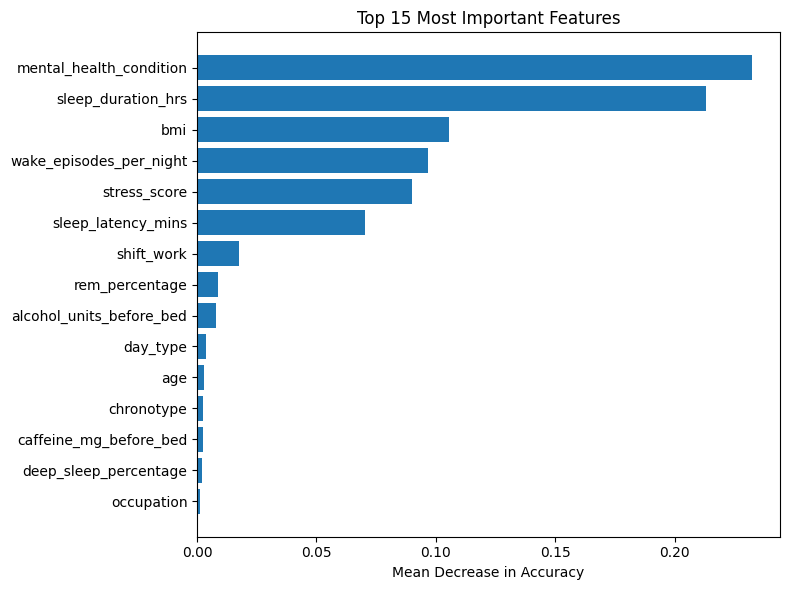

In [20]:
top_n = 15
plot_df = importance_df.head(top_n).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["importance_mean"])
plt.xlabel("Mean Decrease in Accuracy")
plt.title(f"Top {top_n} Most Important Features")
plt.tight_layout()
plt.show()

## 12. Predict Risk for a New Person

This creates one example row using median/mode values from the dataset, then modifies a few inputs.

In [21]:
# Start with a typical person based on the training data
example = X_train.iloc[[0]].copy()

# Modify a few values to create a custom example
updates = {
    "age": 35,
    "bmi": 27.5,
    "sleep_duration_hrs": 5.5,
    "sleep_latency_mins": 30,
    "wake_episodes_per_night": 4,
    "caffeine_mg_before_bed": 120,
    "screen_time_before_bed_mins": 90,
    "stress_score": 7.5,
    "work_hours_that_day": 9.0,
    "shift_work": 0,
    "exercise_day": 0
}

for col, value in updates.items():
    if col in example.columns:
        example.loc[example.index[0], col] = value

prediction = best_pipeline.predict(example)[0]
probabilities = best_pipeline.predict_proba(example)[0]
classes = best_pipeline.classes_

print("Predicted sleep disorder risk:", prediction)

pd.DataFrame({
    "risk_category": classes,
    "predicted_probability": probabilities
}).sort_values("predicted_probability", ascending=False)

Predicted sleep disorder risk: Moderate


,risk_category,predicted_probability
2,Moderate,0.426667
1,Mild,0.413333
3,Severe,0.140000
0,Healthy,0.020000


## 13. Binary Risk Version

For a simpler project, we can convert the target into:

- `No Risk`: Healthy
- `At Risk`: Mild, Moderate, or Severe

In [22]:
# Optional binary target version
# Uncomment this section if you want a binary classifier instead of multiclass classification.

# y_binary = np.where(df[target_col] == "Healthy", "No Risk", "At Risk")
# X_binary = X.copy()
#
# X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
#     X_binary,
#     y_binary,
#     test_size=0.2,
#     random_state=RANDOM_STATE,
#     stratify=y_binary
# )
#
# binary_pipeline = Pipeline(steps=[
#     ("preprocessor", preprocessor),
#     ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
# ])
#
# binary_pipeline.fit(X_train_b, y_train_b)
# y_pred_b = binary_pipeline.predict(X_test_b)
#
# print("Binary Accuracy:", accuracy_score(y_test_b, y_pred_b))
# print(classification_report(y_test_b, y_pred_b))

## 14. Conclusion



> This project built a machine learning classifier to predict sleep disorder risk using lifestyle, health, and sleep behavior data. After preprocessing numeric and categorical features, two models were compared: Logistic Regression and Random Forest. The best-performing model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. Feature importance analysis suggested which factors had the strongest effect on predicted sleep risk. To avoid overly optimistic performance, potentially leaky features such as sleep quality score, cognitive performance score, and felt rested were removed from the main model.